# Gradient Descent and Polynomial Regression

## Overview
In this lab, you will learn how to implement and compare three core optimization strategies used in machine learning:

- **Batch Gradient Descent (BGD)**
- **Stochastic Gradient Descent (SGD)**
- **Mini-Batch Gradient Descent (MBGD)**

You will first study the underlying mathematics and implement these methods **from scratch with NumPy**.
Then you will apply them to **polynomial regression**, analyze their behavior, and complete hands-on exercises.

## Learning Objectives
By the end of this lab, you should be able to:

1. Explain how gradient descent minimizes a cost function.
2. Derive and implement update rules for BGD, SGD, and MBGD.
3. Build polynomial features for nonlinear curve fitting.
4. Compare optimization methods in terms of speed, stability, and final performance.
5. Critically evaluate hyperparameters such as learning rate and batch size.

In [3]:
# =============================
# Imports and visual settings
# =============================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1) Gradient Descent: Concept and Mathematics

### Why Gradient Descent?
For many machine learning models, we define a loss (or cost) function and want to find model parameters that minimize it.
Gradient descent is an iterative optimization algorithm that updates parameters in the direction of the **negative gradient** of the loss.

### Linear Model Form
We use a hypothesis:

$$
\hat{y} = X\theta
$$

where:
- $X \in \mathbb{R}^{m \times n}$ is the design matrix,
- $\theta \in \mathbb{R}^{n \times 1}$ are model parameters,
- $\hat{y} \in \mathbb{R}^{m \times 1}$ are predictions.

### Cost Function (Mean Squared Error)

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

In matrix form:

$$
J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)
$$

### Gradient of MSE

$$
\nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y)
$$

### Update Rule

$$
\theta := \theta - \eta \nabla_\theta J(\theta)
$$

where $\eta$ is the learning rate.

---

## Three Variants

1. **Batch GD**: Uses all training examples each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{m}X^T(X\theta - y)
   $$

2. **Stochastic GD (SGD)**: Uses one sample at a time.
   $$
   \theta := \theta - \eta \cdot x_i^T(x_i\theta - y_i)
   $$

3. **Mini-Batch GD**: Uses a small batch $B$ each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{|B|}X_B^T(X_B\theta - y_B)
   $$

Trade-off intuition:
- Batch: stable but can be slow per update.
- SGD: fast, noisy updates.
- Mini-Batch: balanced and widely used in practice.

In [4]:
class GradientDescentRegressor:
    """
    Linear regressor optimized using batch, stochastic, or mini-batch GD.
    """
    def __init__(self, method="batch", lr=0.01, epochs=200, batch_size=32, random_state=42):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.theta = None
        self.loss_history = []
        self.training_time = None

    def _compute_gradient(self, X, y):
        """Gradient of MSE cost with respect to theta."""
        m = X.shape[0]
        errors = X @ self.theta - y
        grad = (X.T @ errors) / m
        return grad

    def fit(self, X, y):
        """Train model parameters using selected GD method."""
        rng = np.random.default_rng(self.random_state)
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.loss_history = []

        start = time.perf_counter()

        for epoch in range(self.epochs):
            if self.method == "batch":
                grad = self._compute_gradient(X, y)
                self.theta -= self.lr * grad

            elif self.method == "sgd":
                # Shuffle indices each epoch for better stochastic behavior.
                indices = rng.permutation(m)
                for i in indices:
                    Xi = X[i:i+1]
                    yi = y[i:i+1]
                    grad = Xi.T @ (Xi @ self.theta - yi)  # batch size is 1
                    self.theta -= self.lr * grad

            elif self.method == "mini-batch":
                indices = rng.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_idx = indices[start_idx:start_idx + self.batch_size]
                    Xb = X[batch_idx]
                    yb = y[batch_idx]
                    grad = (Xb.T @ (Xb @ self.theta - yb)) / Xb.shape[0]
                    self.theta -= self.lr * grad

            else:
                raise ValueError("method must be 'batch', 'sgd', or 'mini-batch'")

            # Track full-dataset loss after each epoch.
            y_pred_epoch = X @ self.theta
            epoch_loss = mean_squared_error(y, y_pred_epoch)
            self.loss_history.append(epoch_loss)

        end = time.perf_counter()
        self.training_time = end - start
        return self

    def predict(self, X):
        """Predict targets for input matrix X."""
        return X @ self.theta

## 2) Simple Example: Compare BGD, SGD, and MBGD

We start with a simple linear dataset to compare convergence behavior of the three methods.

Model: $y = 4 + 3x + \epsilon$

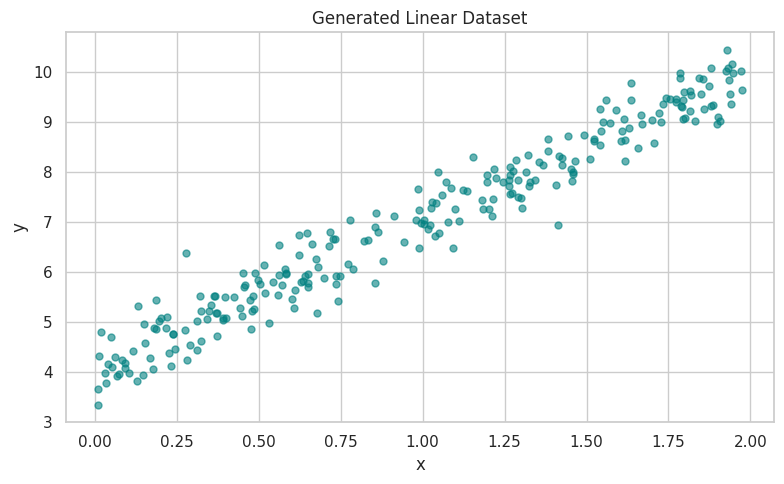

,Method,Final MSE,Training Time (s),Final Theta
0,Batch GD,0.218234,0.073093,"[3.606754282347466, 3.3500936172456846]"
1,SGD,0.156999,0.301536,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.116506,"[4.054809763947758, 2.9712473416164924]"


In [5]:
# Generate synthetic linear data
m = 250
X_raw = 2 * np.random.rand(m, 1)
noise = np.random.randn(m, 1) * 0.4
y = 4 + 3 * X_raw + noise

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, alpha=0.6, s=25, color="teal")
plt.title("Generated Linear Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Add bias term for linear model
X = np.c_[np.ones((X_raw.shape[0], 1)), X_raw]

# Train all three variants
models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.08, epochs=50),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.01, epochs=50),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.03, epochs=50, batch_size=16)
}

results_simple = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    results_simple.append({
        "Method": name,
        "Final MSE": mean_squared_error(y, y_pred),
        "Training Time (s)": model.training_time,
        "Final Theta": model.theta.ravel()
    })

simple_results_df = pd.DataFrame(results_simple)
simple_results_df

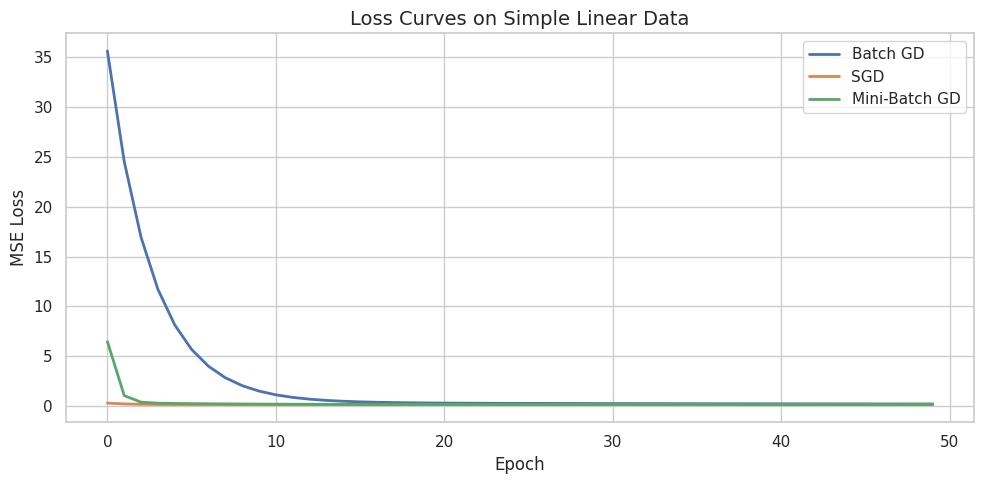

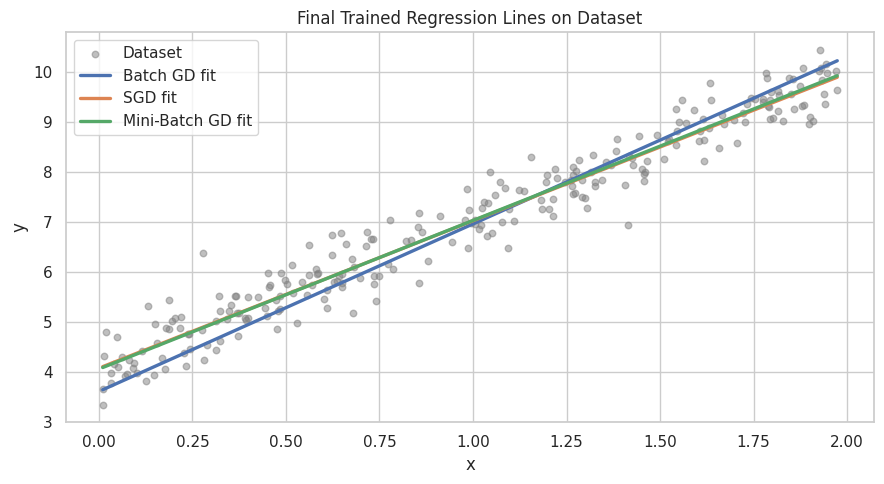

,Method,Final MSE,Training Time (s),Final Theta
1,SGD,0.156999,0.301536,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.116506,"[4.054809763947758, 2.9712473416164924]"
0,Batch GD,0.218234,0.073093,"[3.606754282347466, 3.3500936172456846]"


In [6]:
# Plot loss curves to compare convergence
plt.figure(figsize=(10, 5))
for name, model in models.items():
    plt.plot(model.loss_history, label=name, linewidth=2)

plt.title("Loss Curves on Simple Linear Data", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize final trained regression lines on top of the dataset
x_line = np.linspace(X_raw.min(), X_raw.max(), 300).reshape(-1, 1)
X_line = np.c_[np.ones((x_line.shape[0], 1)), x_line]

plt.figure(figsize=(9, 5))
plt.scatter(X_raw, y, alpha=0.5, s=22, color="gray", label="Dataset")
for name, model in models.items():
    y_line_pred = model.predict(X_line)
    plt.plot(x_line, y_line_pred, linewidth=2.4, label=f"{name} fit")

plt.title("Final Trained Regression Lines on Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

display(simple_results_df.sort_values("Final MSE"))

### Interpretation
- **Batch GD** usually gives smoother convergence because each update uses the full dataset.
- **SGD** often converges quickly at first but exhibits noisier loss curves.
- **Mini-Batch GD** balances stability and computational efficiency.

In practice, mini-batch methods are widely used because they are GPU-friendly and often converge well.

## 3) Polynomial Regression from Scratch

### Why Polynomial Features?
A linear model in the original feature space can only fit straight lines/planes.
If the relationship between $x$ and $y$ is nonlinear, we can map input $x$ to polynomial features:

$$
\phi(x) = [x, x^2, x^3, \dots, x^d]
$$

Then fit a linear model in transformed space:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d
$$

This is still linear in parameters $\theta$, so gradient descent applies directly.

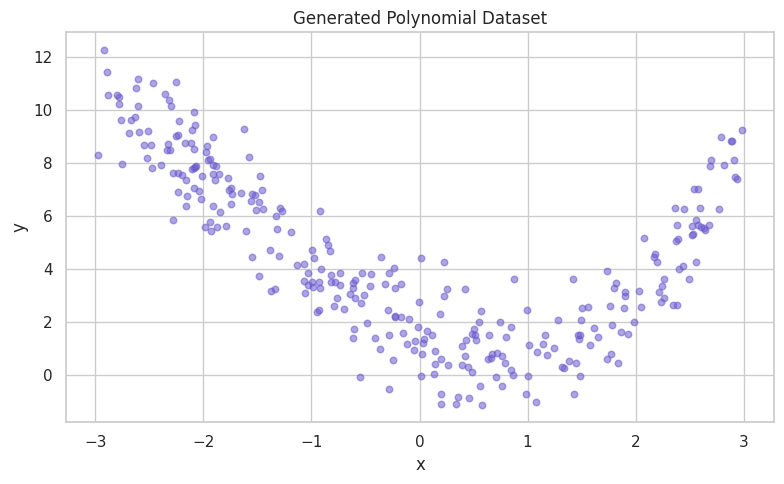

Polynomial data prepared.
Design matrix shape: (300, 4)


In [7]:
# Generate synthetic polynomial data
m_poly = 300
x_poly = np.random.uniform(-3, 3, size=(m_poly, 1))
y_poly = 1.5 - 2.0 * x_poly + 0.9 * (x_poly ** 2) + 0.2 * (x_poly ** 3) + np.random.randn(m_poly, 1) * 1.2

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(x_poly, y_poly, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Create polynomial features up to degree 3 using sklearn
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly_raw = poly.fit_transform(x_poly)

# Standardize polynomial features for stable GD updates using sklearn
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_raw)

# Add explicit bias for our from-scratch GD implementation
X_poly_design = np.c_[np.ones((X_poly_scaled.shape[0], 1)), X_poly_scaled]

print("Polynomial data prepared.")
print("Design matrix shape:", X_poly_design.shape)

In [8]:
# Train polynomial regression with all three GD variants
poly_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=250),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=250),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.02, epochs=250, batch_size=32)
}

poly_results = []
for name, model in poly_models.items():
    model.fit(X_poly_design, y_poly)
    y_pred = model.predict(X_poly_design)

    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    poly_results.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_poly, y_pred),
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df

,Method,Final MSE,Epochs to Converge,Training Time (s)
0,Batch GD,1.424179,195,0.213548
1,SGD,1.292687,12,1.491574
2,Mini-Batch GD,1.292398,86,0.203214


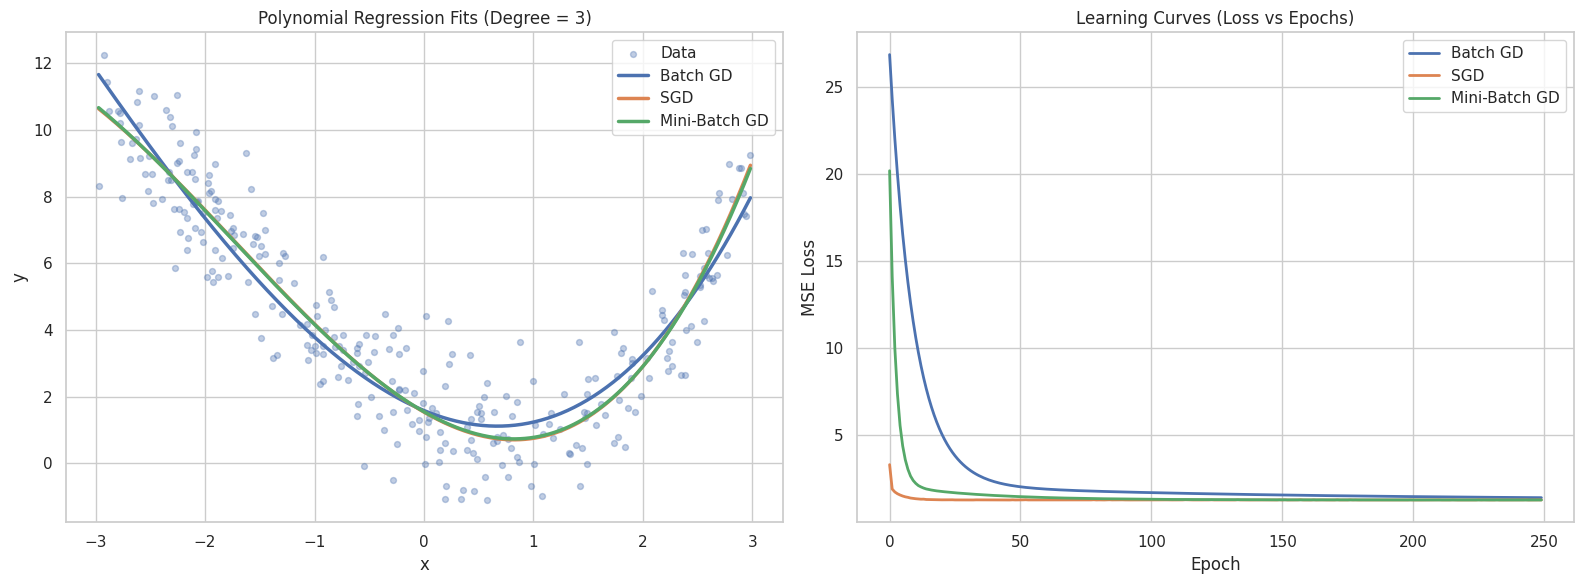

,Method,Final MSE,Epochs to Converge,Training Time (s)
2,Mini-Batch GD,1.292398,86,0.203214
1,SGD,1.292687,12,1.491574
0,Batch GD,1.424179,195,0.213548


In [9]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(x_poly.min(), x_poly.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(x_poly, y_poly, alpha=0.35, s=18, label="Data")
for name, model in poly_models.items():
    y_grid_pred = model.predict(X_grid_design)
    axes[0].plot(x_grid, y_grid_pred, linewidth=2.5, label=name)

axes[0].set_title("Polynomial Regression Fits (Degree = 3)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: learning curves
for name, model in poly_models.items():
    axes[1].plot(model.loss_history, linewidth=2, label=name)

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

display(poly_results_df.sort_values("Final MSE"))

### Observations
- All three methods can fit polynomial regression when features are engineered properly.
- Feature scaling is critical for numerical stability, especially for high-degree polynomial terms.
- SGD may oscillate more due to noisy updates, while Batch GD is smoother.
- Mini-Batch GD often gives a strong practical compromise.

# 4) Lab Exercises (Total: 100 points)

Complete the following tasks. Write clean code, include plots, and explain your findings in markdown.

## Task 1 (25 points)
**Implement Batch Gradient Descent from scratch** for a 4nd-degree polynomial regression on a new synthetic dataset (use different coefficients and noise from tutorial).

### Requirements
- Generate your own dataset.
- Build polynomial features (degree 4).
- Train using Batch GD.
- Plot fitted curve and learning curve.

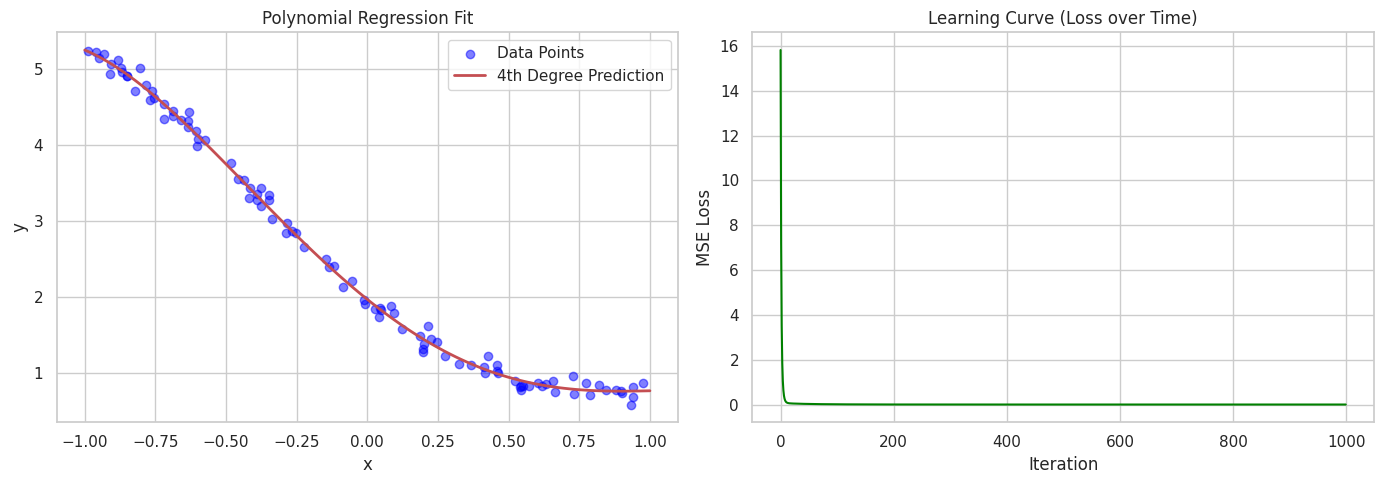

Final Theta Coefficients (Scaled Space):
[[ 2.57135176]
 [-1.77001327]
 [ 0.49444705]
 [ 0.29018   ]
 [-0.16632274]]


In [10]:
# -----------------------------
# Task 1 starter template
# -----------------------------
# TODO: Generate a new synthetic quadratic dataset with different coefficients/noise.
# Example target form: y = a + b*x + c*x^2 + d*x^3 + e*x^4 + noise

# x_t1 = ...
# y_t1 = ...

# TODO: Build degree-4 polynomial features and standardize using sklearn.

# TODO: Train Batch GD.

# TODO: Plot fitted curve and loss curve.
# (Reuse plotting style from tutorial.)#

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Generate Synthetic Dataset
# -----------------------------
np.random.seed(42)
m = 100
# Target: y = 2 - 3x + 1.5x^2 + 0.8x^3 - 0.5x^4 + noise
x_t1 = 2 * np.random.rand(m, 1) - 1  # Range [-1, 1]
noise = 0.1 * np.random.randn(m, 1)
y_t1 = 2 - 3*x_t1 + 1.5*x_t1**2 + 0.8*x_t1**3 - 0.5*x_t1**4 + noise

# -----------------------------
# 2. Build Polynomial Features
# -----------------------------
# Manual feature expansion: [1, x, x^2, x^3, x^4]
X_poly = np.c_[np.ones((m, 1)), x_t1, x_t1**2, x_t1**3, x_t1**4]

# Standardize features (excluding bias) to help GD converge
scaler = StandardScaler()
X_poly_scaled = np.c_[np.ones((m, 1)), scaler.fit_transform(X_poly[:, 1:])]

# -----------------------------
# 3. Train using Batch Gradient Descent
# -----------------------------
eta = 0.1  # Learning rate
n_iterations = 1000
theta = np.random.randn(5, 1)  # Random initialization
loss_history = []

for iteration in range(n_iterations):
    gradients = 2/m * X_poly_scaled.T.dot(X_poly_scaled.dot(theta) - y_t1)
    theta = theta - eta * gradients

    # Calculate Mean Squared Error for the learning curve
    loss = np.mean((X_poly_scaled.dot(theta) - y_t1)**2)
    loss_history.append(loss)

# -----------------------------
# 4. Plotting
# -----------------------------
plt.figure(figsize=(14, 5))

# Plot 1: Fitted Curve
plt.subplot(1, 2, 1)
x_new = np.linspace(-1, 1, 100).reshape(100, 1)
x_new_poly = np.c_[np.ones((100, 1)), x_new, x_new**2, x_new**3, x_new**4]
x_new_scaled = np.c_[np.ones((100, 1)), scaler.transform(x_new_poly[:, 1:])]
y_predict = x_new_scaled.dot(theta)

plt.scatter(x_t1, y_t1, color='blue', alpha=0.5, label='Data Points')
plt.plot(x_new, y_predict, 'r-', linewidth=2, label='4th Degree Prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression Fit')
plt.legend()

# Plot 2: Learning Curve
plt.subplot(1, 2, 2)
plt.plot(loss_history, color='green')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Learning Curve (Loss over Time)')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Final Theta Coefficients (Scaled Space):")
print(theta)

## Task 2 (25 points)
**Implement Stochastic Gradient Descent (SGD)** and tune the learning rate.

### Requirements
- Use one polynomial dataset.
- Try multiple learning rates (e.g., 0.0005, 0.001, 0.005, 0.01).
- Plot loss curves for each learning rate.
- Explain underfitting/divergence/instability if observed.

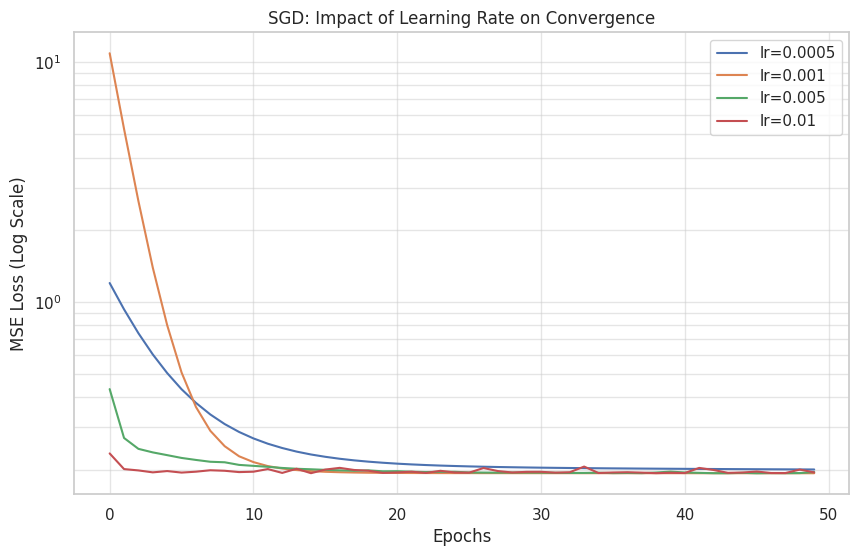

In [15]:
# -----------------------------
# Task 2 starter template
# -----------------------------
learning_rates = [0.0005, 0.001, 0.005, 0.01]
sgd_histories = {}

# TODO: Reuse or regenerate a polynomial dataset.


for lr in learning_rates:
    # TODO: Train SGD with each learning rate.
    pass

# TODO: Plot all loss curves on one figure.

# TODO: Add markdown analysis of learning-rate effects.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Dataset Generation (Degree 3 for variety)
np.random.seed(42)
m = 100
x = 2 * np.random.rand(m, 1) - 1
y = 1.5 + 2*x - 3*x**2 + 5*x**3 + np.random.randn(m, 1) * 0.5

# Build and scale features
X_poly = np.c_[np.ones((m, 1)), x, x**2, x**3]
scaler = StandardScaler()
X_poly_scaled = np.c_[np.ones((m, 1)), scaler.fit_transform(X_poly[:, 1:])]

# 2. SGD Implementation
learning_rates = [0.0005, 0.001, 0.005, 0.01]
n_epochs = 50
sgd_histories = {}

for lr in learning_rates:
    theta = np.random.randn(4, 1)
    losses = []

    for epoch in range(n_epochs):
        # Shuffle at the start of each epoch
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_poly_scaled[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_b_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - lr * gradients

        # Calculate loss at the end of epoch for tracking
        epoch_loss = np.mean((X_poly_scaled.dot(theta) - y)**2)
        losses.append(epoch_loss)

    sgd_histories[lr] = losses

# 3. Plotting
plt.figure(figsize=(10, 6))
for lr, history in sgd_histories.items():
    plt.plot(history, label=f'lr={lr}')

plt.yscale('log') # Log scale helps visualize divergence vs convergence
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Log Scale)')
plt.title('SGD: Impact of Learning Rate on Convergence')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

## Task 3 (25 points)
**Implement Mini-Batch Gradient Descent** and study different batch sizes.

### Requirements
- Try batch sizes: 8, 16, 32, 64.
- Keep other settings fixed (same learning rate, epochs, dataset).
- Plot loss curves for each batch size.
- Analyze trade-off: convergence speed vs stability.

Starting Mini-Batch GD training with different batch sizes...
Training Mini-Batch GD with batch size: 8
Training Mini-Batch GD with batch size: 16
Training Mini-Batch GD with batch size: 32
Training Mini-Batch GD with batch size: 64
Training Mini-Batch GD with batch size: 128


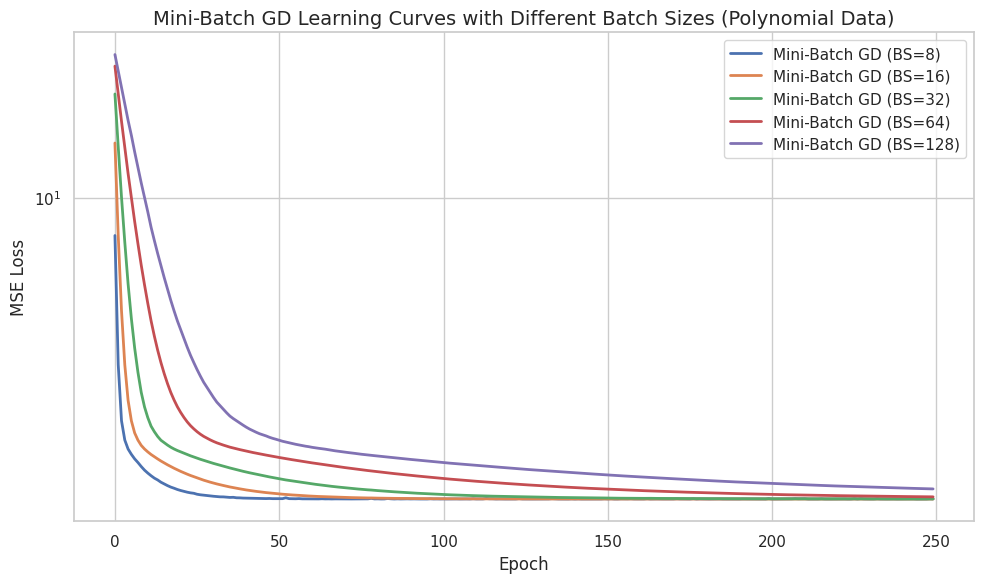

,Batch Size,Final MSE,Training Time (s)
1,16,1.291821,0.224191
2,32,1.292398,0.176049
0,8,1.292779,0.556811
3,64,1.310937,0.164952
4,128,1.383393,0.235182


In [16]:
# -----------------------------
# Task 3 starter template
# -----------------------------
batch_sizes = [8, 16, 32, 64]
mbgd_histories = {}
mbgd_metrics = []

# TODO: Reuse a consistent polynomial dataset from Task 2 or create one.
# X_t3, y_t3 = ...

for bs in batch_sizes:
    # TODO: Train Mini-Batch GD for each batch size.

    # mbgd_histories[bs] = model.loss_history
    # mbgd_metrics.append({"Batch Size": bs, "Final MSE": mean_squared_error(y_t3, model.predict(X_t3)), "Time": model.training_time})
    pass

# TODO: Plot loss curves and display metric table.
# pd.DataFrame(mbgd_metrics)

# TODO: Add markdown analysis about stability and speed.

# -----------------------------
# Task 3 starter template
# -----------------------------
batch_sizes = [8, 16, 32, 64, 128]
mbgd_histories = {}
mbgd_metrics = []

# Reuse a consistent polynomial dataset from Task 2.
X_t3 = X_poly_design # From poly-data-generation
y_t3 = y_poly # From poly-data-generation

print("Starting Mini-Batch GD training with different batch sizes...")
fixed_lr = 0.02 # Using a reasonable learning rate for MBGD
fixed_epochs = 250

for bs in batch_sizes:
    print(f"Training Mini-Batch GD with batch size: {bs}")
    # Train Mini-Batch GD for each batch size.
    mbgd_model = GradientDescentRegressor(method="mini-batch", lr=fixed_lr, epochs=fixed_epochs, batch_size=bs, random_state=42)
    mbgd_model.fit(X_t3, y_t3)
    mbgd_histories[bs] = mbgd_model.loss_history

    y_pred_t3 = mbgd_model.predict(X_t3)
    mbgd_metrics.append({"Batch Size": bs, "Final MSE": mean_squared_error(y_t3, y_pred_t3), "Training Time (s)": mbgd_model.training_time})

# Plot all loss curves on one figure.
plt.figure(figsize=(10, 6))
for bs, history in mbgd_histories.items():
    plt.plot(history, label=f'Mini-Batch GD (BS={bs})', linewidth=2)

plt.title("Mini-Batch GD Learning Curves with Different Batch Sizes (Polynomial Data)", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale('log') # Use log scale for y-axis if needed for better visualization
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display metric table.
mbgd_results_df = pd.DataFrame(mbgd_metrics)
display(mbgd_results_df.sort_values("Final MSE"))

## Task 4 (25 points)
**Compare Batch, SGD, and Mini-Batch GD** on the same polynomial regression dataset.

### Required comparison outputs
- Final MSE
- Number of epochs to converge
- Training time
- Final fitted curve quality (visual inspection)

Present a summary table and at least one comparison plot.

       Method Final MSE  Epochs Time (s)
     Batch GD   0.03691     200   0.0190
          SGD   0.03707      50   0.1951
Mini-Batch GD   0.03662     100   0.0361


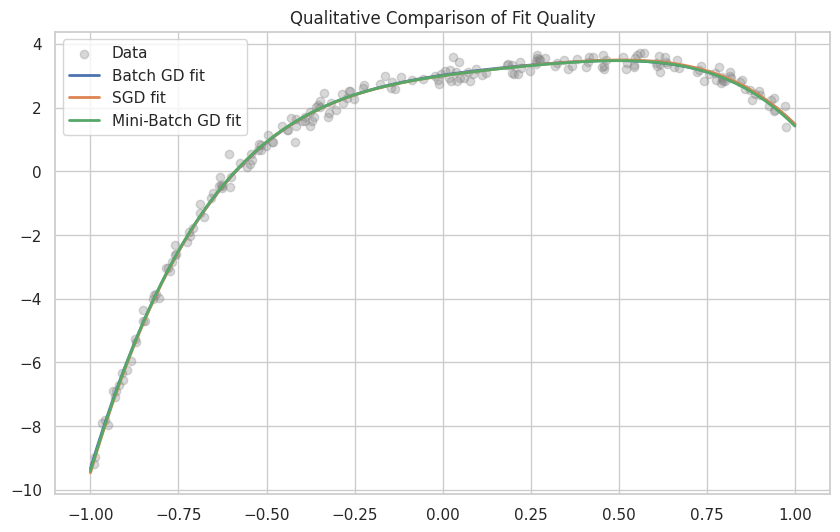

In [17]:
# -----------------------------
# Task 4 starter template
# -----------------------------
# TODO: Use one shared dataset and preprocessing.
# X_t4, y_t4 = ...

task4_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=..., epochs=...),
    "SGD": GradientDescentRegressor(method="sgd", lr=..., epochs=...),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=..., epochs=..., batch_size=...)
}

task4_rows = []
for name, model in task4_models.items():
    pass

# TODO: Build summary table and visualization.
# summary_df = pd.DataFrame(task4_rows)
# display(summary_df)

# TODO: Plot fitted curves on the same graph for qualitative comparison.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import StandardScaler

# 1. Setup shared dataset (Degree 4)
np.random.seed(42)
m = 200
x = 2 * np.random.rand(m, 1) - 1
y = 3 + 1.5*x - 2*x**2 + 4*x**3 - 5*x**4 + np.random.randn(m, 1) * 0.2

X_poly = np.c_[np.ones((m, 1)), x, x**2, x**3, x**4]
scaler = StandardScaler()
X_scaled = np.c_[np.ones((m, 1)), scaler.fit_transform(X_poly[:, 1:])]

# 2. General GD Class to handle all three methods
class GradientDescentRegressor:
    def __init__(self, method="batch", lr=0.01, epochs=100, batch_size=20):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.theta = None
        self.history = []

    def fit(self, X, y):
        m_samples, n_features = X.shape
        self.theta = np.random.randn(n_features, 1)
        start_time = time.time()

        for epoch in range(self.epochs):
            if self.method == "batch":
                gradients = 2/m_samples * X.T.dot(X.dot(self.theta) - y)
                self.theta -= self.lr * gradients

            elif self.method == "sgd":
                indices = np.random.permutation(m_samples)
                for i in indices:
                    xi = X[i:i+1]
                    yi = y[i:i+1]
                    gradients = 2 * xi.T.dot(xi.dot(self.theta) - yi)
                    self.theta -= self.lr * gradients

            elif self.method == "mini-batch":
                indices = np.random.permutation(m_samples)
                X_shuf, y_shuf = X[indices], y[indices]
                for i in range(0, m_samples, self.batch_size):
                    xi = X_shuf[i:i+self.batch_size]
                    yi = y_shuf[i:i+self.batch_size]
                    gradients = 2/len(xi) * xi.T.dot(xi.dot(self.theta) - yi)
                    self.theta -= self.lr * gradients

            self.history.append(np.mean((X.dot(self.theta) - y)**2))

        return time.time() - start_time

# 3. Execution and Data Collection
models = {
    "Batch GD": {"lr": 0.1, "epochs": 200},
    "SGD": {"lr": 0.01, "epochs": 50},
    "Mini-Batch GD": {"lr": 0.05, "epochs": 100, "batch_size": 16}
}

task4_rows = []
predictions = {}

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.3, label="Data", color='gray')

for name, cfg in models.items():
    model = GradientDescentRegressor(method=name.lower().replace(" gd", ""), **cfg)
    duration = model.fit(X_scaled, y)

    final_mse = model.history[-1]
    task4_rows.append({"Method": name, "Final MSE": f"{final_mse:.5f}",
                       "Epochs": cfg['epochs'], "Time (s)": f"{duration:.4f}"})

    # Generate curve for plotting
    x_range = np.linspace(-1, 1, 100).reshape(-1, 1)
    X_range_poly = np.c_[np.ones((100, 1)), x_range, x_range**2, x_range**3, x_range**4]
    X_range_scaled = np.c_[np.ones((100, 1)), scaler.transform(X_range_poly[:, 1:])]
    y_pred = X_range_scaled.dot(model.theta)
    plt.plot(x_range, y_pred, label=f"{name} fit", lw=2)

# 4. Summary Table
summary_df = pd.DataFrame(task4_rows)
print(summary_df.to_string(index=False))

# 5. Finalize Plot
plt.title("Qualitative Comparison of Fit Quality")
plt.legend()
plt.show()

# 5) Bonus Questions (Theoretical - 10 points)

Answer the following conceptual questions in your own words.

### 1) (4 points)
**Explain the bias-variance tradeoff in the context of choosing the degree of the polynomial. What happens if the degree is too low or too high?**

**Your answer:**

_Write your response here..._

### 2) (3 points)
**Why does Stochastic Gradient Descent have higher variance in parameter updates compared to Batch Gradient Descent? How does Mini-Batch GD try to balance this?**

**Your answer:**

_Write your response here..._

### 3) (3 points)
**Discuss the importance of feature scaling when using Gradient Descent for polynomial regression. What problems can arise without scaling?**

**Your answer:**

_Write your response here..._

# 6) Conclusion

In this lab, you:
- Implemented **Batch GD**, **SGD**, and **Mini-Batch GD** from scratch using NumPy.
- Compared optimization behavior through loss curves and empirical metrics.
- Applied gradient descent methods to **polynomial regression** with feature engineering.
- Explored practical tuning effects of learning rate and batch size.

Key takeaway: there is no single universally best optimizer setup. Effective training depends on balancing learning rate, batch size, feature scaling, and computational constraints.